In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [3]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data(0)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
X_train.shape

(60000, 28, 28)

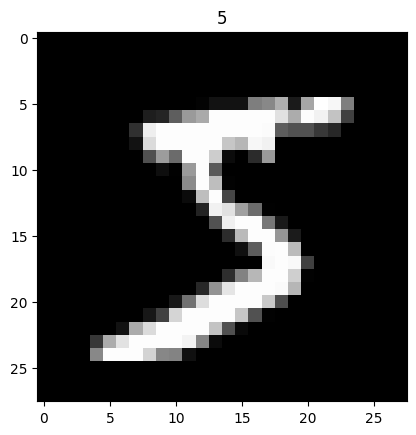

In [6]:
plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.show()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [9]:
X_train.shape

(60000, 28, 28, 1)

In [11]:
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1 )),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")

])

d:\AI Journey\ai-journey\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics =  ["accuracy"]
)

In [14]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9549 - loss: 0.1491
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9859 - loss: 0.0465
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9905 - loss: 0.0312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9923 - loss: 0.0239
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9942 - loss: 0.0176


In [15]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9898 - loss: 0.0330


[0.03296523168683052, 0.989799976348877]

Load image dataset
↓
Normalize pixel values
↓
Reshape for CNN
↓
Build CNN architecture
↓
Train model
↓
Evaluate on test data

Conv2D → MaxPooling
↓
Conv2D → MaxPooling
↓
Flatten
↓
Dense
↓
Softmax output (10 digits)

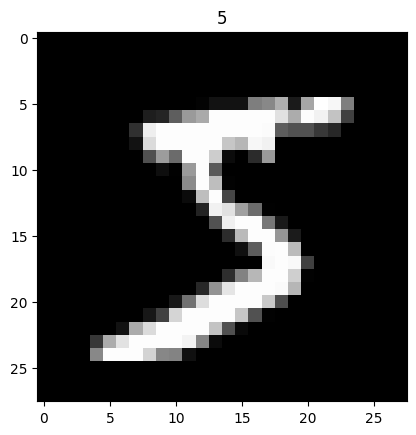

In [19]:
plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.savefig("minst_sample_digits.png")
plt.show()

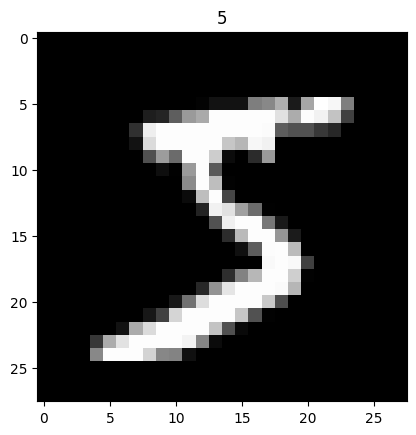

In [20]:
plt.imshow(X_train[0].reshape(28,28), cmap="gray")
plt.title(y_train[0])
plt.savefig("minst_sample_digits_example.png")
plt.show()

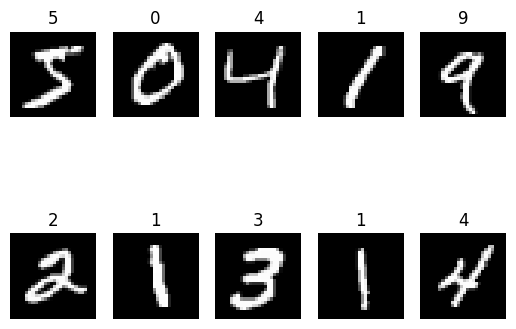

In [21]:
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.savefig("cnn_prediction_example.png")
plt.show()